In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Метод главных компонент (Principal Component Analysis, PCA)**

Алгоритмы обучения без учителя для **уменьшения размерности (dimension reduction)**

Как визуализировать 30+ измерений, когда мы максимум можем визуилизировать 4 (мы живем в 3Д мире + 4-е измерение в hue)

## **Теория**

**Результаты уменьшения размерности**:
- Понимание того, какие признаки объясняют большую часть вариации в данных
- Помогают людям лучше понимать большие и сложные наборы данных

Правильнее назвать **трансформация**, а не уменьшение размерности. Во время трансформации мы так же уменьшаем размерность уже *нового* пространства признаков

**Важное замечание**

Уменьшение размерности **НЕ выбирает только некторые из имеющихся признаков**

Мы создаем *новые признаки* на основе комбинаций уже существующих признаков в некоторых пропорциях

**ЦЕЛЬ**

Взять сложный набор данных, и найти в них главные компоненты

Для 30 признаков, но 500 строк можно построить Heatmap, но это уже не очень информативно даже при небольшом кол-ве строк, как здесь

Все измерения --> некоторые комбинации измерения

**Объяснение Вариативности (Variance Explained)**

Некоторые признаки могут быть важнее других признаков

В задачи определения Цены продажи дома размер дома важнее цвета фасада дома

Мы можем измерить пропорцию, в которой признаки отвечают за вариативность в данных

*Главная компонента* - линейная комбинация исходных признаков.

Чем больше какой-то признак объясняет вариативность в данных, тем больше он участвует в главных компонентах

Пример

От двух признаков перешли к 1 главной компоненте

1 главная компонента может "объяснить" 90% вариативности в исходных даннхы. Остальные 10% потерялись

**Баланс между полнотой объяснения вариативности и уменьшением размерности**

**Метод главных компонент создаёт новый набор измерений (главных компонент),**

**которые являются линейными комбинациями исходных признаков.**

$$Z_1 = \phi_{11}X_1 + \phi_{21}X_2 + \ldots + \phi_{p1}X_p $$

Использовать проецирование всех точек на измерение

1) Нанести точки на график
2) Стандартизация данных

**Шаги метода главных компонент**
- Берём исходные данные
- Вычисляем ковариационную матрицу
- Вычисляем собственные вектора (EigenVectors)
- Сортируем их по собственным значениям
- Берём N наибольших собственных значений
- Проецируем данные на собственные вектора

## **Ручная реализация**

In [4]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cancer_tumor_data_features.csv")

Данные о раковых опухолях

In [5]:
df.shape

(569, 30)

In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
#sns.heatmap(df)

Надо сделать так, чтобы ноль оказался в середине координат

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
scaled_X = scaler.fit_transform(df)

In [13]:
scaled_X.mean() # Это 0

np.float64(-6.53516165871914e-17)

In [14]:
scaled_X.mean(axis=0)

array([-1.37363271e-16,  6.86816353e-17, -1.24875700e-16, -2.18532476e-16,
       -8.36667193e-16,  1.87313551e-16,  4.99502802e-17, -4.99502802e-17,
        1.74825981e-16,  4.74527662e-16,  2.37263831e-16, -1.12388130e-16,
       -1.12388130e-16, -1.31119486e-16, -1.52972733e-16,  1.74825981e-16,
        1.62338411e-16,  0.00000000e+00,  8.74129903e-17, -6.24378502e-18,
       -8.24179623e-16,  1.24875700e-17, -3.74627101e-16,  0.00000000e+00,
       -2.37263831e-16, -3.37164391e-16,  7.49254203e-17,  2.24776261e-16,
        2.62238971e-16, -5.74428222e-16])

In [22]:
covariance_matrix = np.cov(scaled_X, rowvar=False)

In [23]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [24]:
eigen_values

array([1.33049908e+01, 5.70137460e+00, 2.82291016e+00, 1.98412752e+00,
       1.65163324e+00, 1.20948224e+00, 6.76408882e-01, 4.77456255e-01,
       4.17628782e-01, 3.51310875e-01, 2.94433153e-01, 2.61621161e-01,
       2.41782421e-01, 1.57286149e-01, 9.43006956e-02, 8.00034045e-02,
       5.95036135e-02, 5.27114222e-02, 4.95647002e-02, 1.33279057e-04,
       7.50121413e-04, 1.59213600e-03, 6.91261258e-03, 8.19203712e-03,
       1.55085271e-02, 1.80867940e-02, 2.43836914e-02, 2.74877113e-02,
       3.12142606e-02, 3.00256631e-02])

In [25]:
eigen_vectors.shape

(30, 30)

In [27]:
np.argsort([2, 1, 3]) # отсортированные индексы, а не значения!

array([1, 0, 2])

In [26]:
num_components = 2

In [31]:
sorted_key = np.argsort(eigen_values)[::-1][:num_components]

In [32]:
eigen_values, eigen_vectors = eigen_values[sorted_key], eigen_vectors[:, sorted_key]

Проекция данных на две выбранные главные компоненты

In [33]:
principal_components = np.dot(scaled_X, eigen_vectors) # 30 --> 2

In [35]:
principal_components

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

МЫ СОХРАНИЛИ возможность разделить данные на 2 класса при переходе от 30 колонок к 2

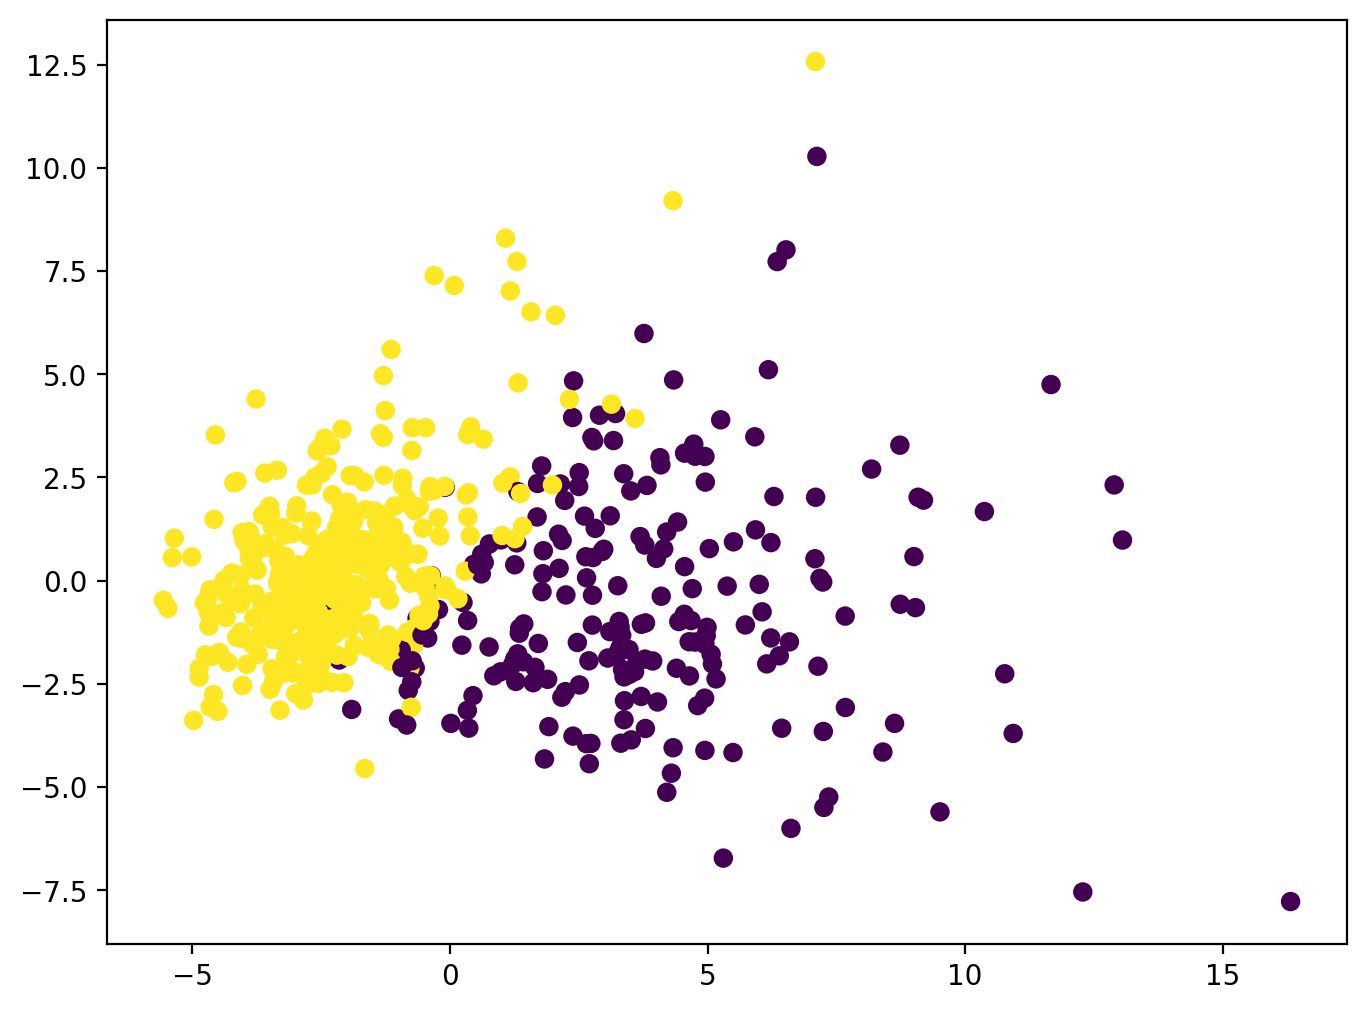

In [48]:
plt.figure(figsize=(8,6), dpi=200)
plt.scatter(principal_components[:, 0], principal_components[:, 1],c=cancer_dictionary['target'])

In [40]:
from sklearn.datasets import load_breast_cancer

In [41]:
cancer_dictionary = load_breast_cancer()

In [42]:
type(cancer_dictionary)

sklearn.utils._bunch.Bunch

In [43]:
cancer_dictionary.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [45]:
#print(cancer_dictionary.DESCR)

In [46]:
#df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cancer_tumor_data_features.csv")

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

## **PCA Scikit-learn**

In [56]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cancer_tumor_data_features.csv")

In [51]:
from sklearn.decomposition import PCA

In [50]:
from sklearn.pipeline import make_pipeline

In [57]:
pipe = make_pipeline(StandardScaler(), PCA(n_components=2))

In [58]:
pc_results = pipe.fit_transform(df)

In [59]:
pc_results

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

Получаем точно такой же график, как и в "ручная реализация", но буквально в пару строчек кода.

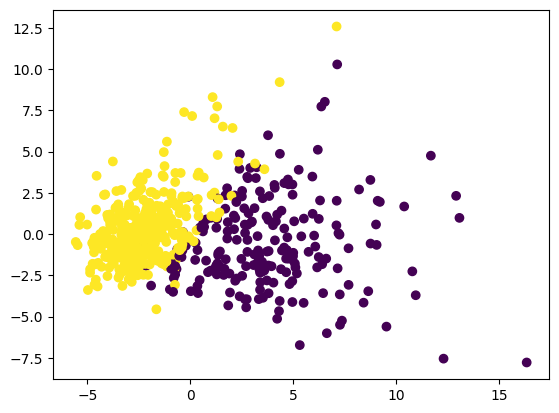

In [61]:
plt.scatter(pc_results[:, 0], pc_results[:, 1], c=cancer_dictionary['target'])

In [63]:
pipe.named_steps

{'standardscaler': StandardScaler(), 'pca': PCA(n_components=2)}

In [66]:
pipe['pca'].components_

array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
         0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
         0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
         0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
         0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
         0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
       [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
         0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
        -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
         0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
        -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
         0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947]])

In [67]:
df_components = pd.DataFrame(pipe['pca'].components_, index=['PC1', 'PC2'], columns=df.columns)

In [68]:
df_components

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
PC1,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
PC2,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339


<Axes: >

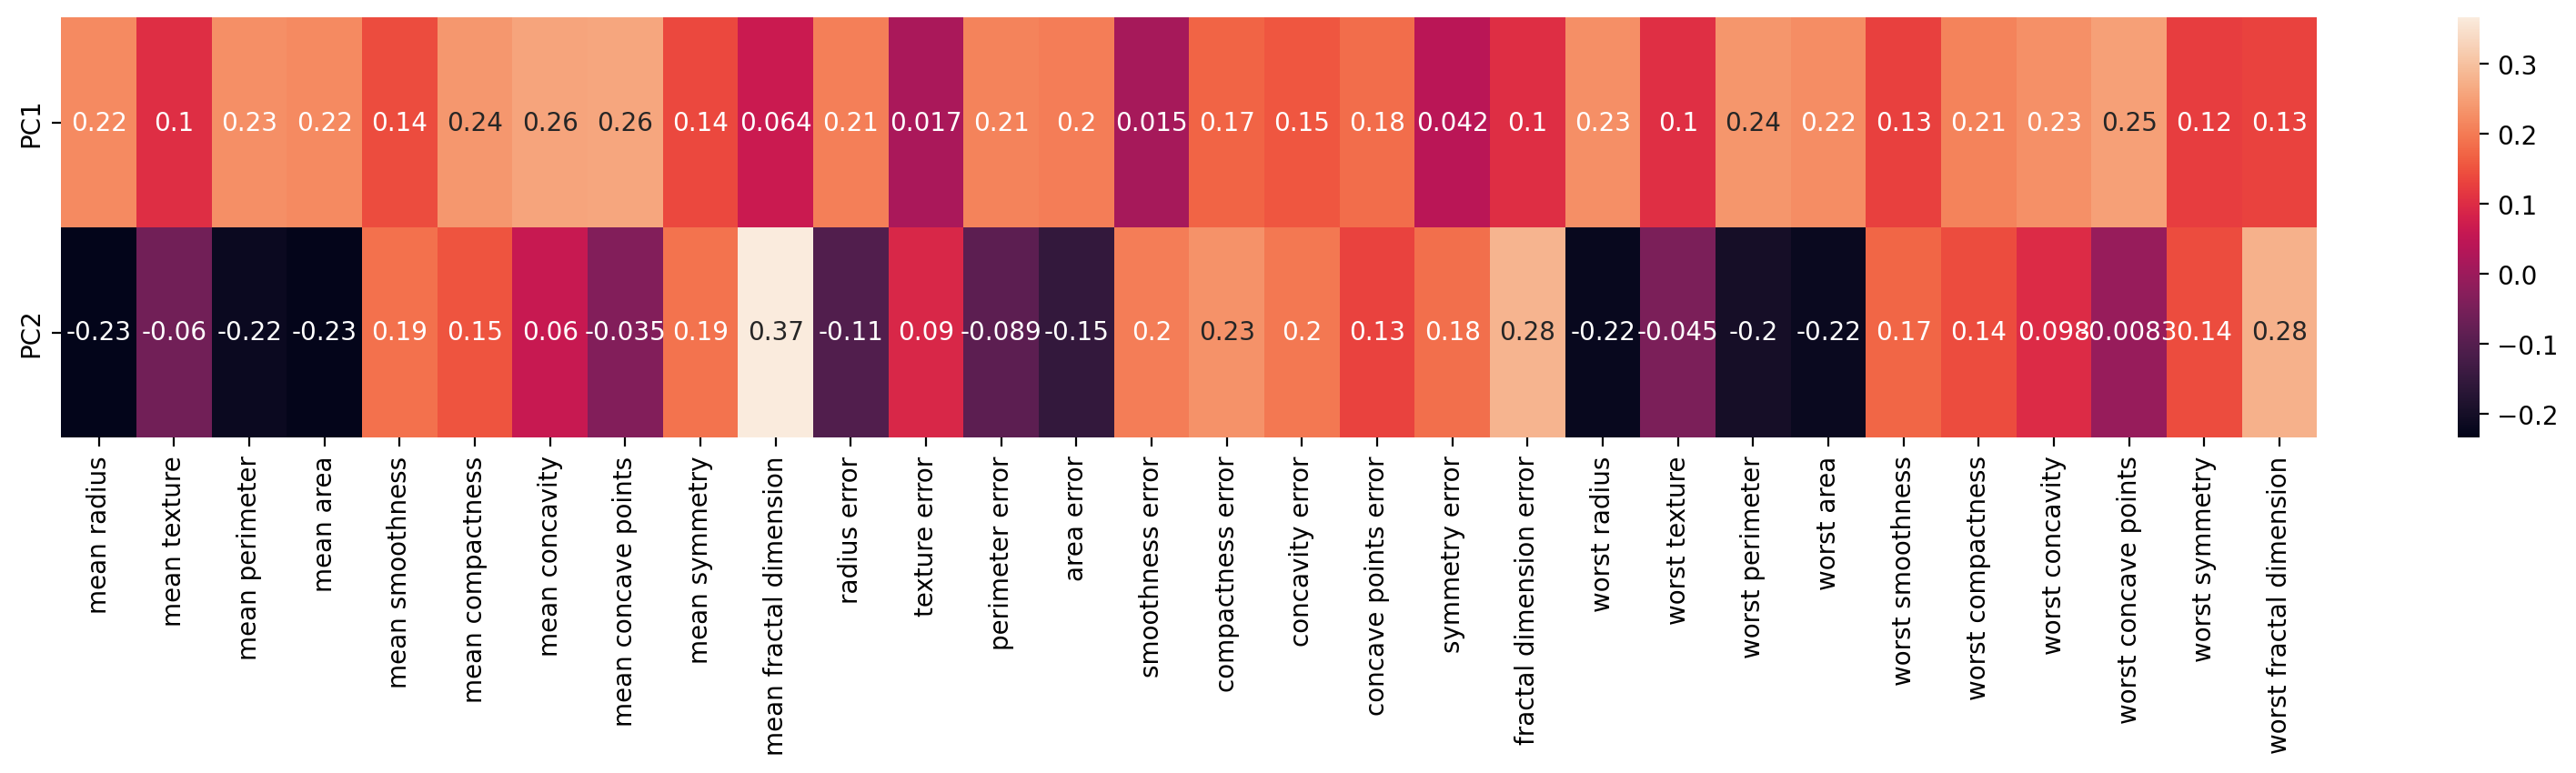

In [70]:
plt.figure(figsize=(20, 3), dpi=200)
sns.heatmap(data=df_components, annot=True)

In [71]:
pipe['pca'].explained_variance_ratio_

array([0.44272026, 0.18971182])

In [72]:
np.sum(pipe['pca'].explained_variance_ratio_)

np.float64(0.6324320765155944)

Всего лишь 2 компонента могут объяснить 63% вариативности данных

In [74]:
pipe_30 = make_pipeline(StandardScaler(), PCA(n_components=30))

In [76]:
pc_30_res = pipe_30.fit_transform(df)

In [78]:
np.sum(pipe_30['pca'].explained_variance_ratio_)

np.float64(1.0000000000000002)

In [80]:
scaler = StandardScaler()

In [81]:
scaled_X = scaler.fit_transform(df)

In [82]:
explained_variance = []
for n in range(1, 30):
    pca = PCA(n_components=n)
    pca.fit(scaled_X)
    explained_variance.append(np.sum(pca.explained_variance_ratio_))

(0.0, 1.0278593306274382)

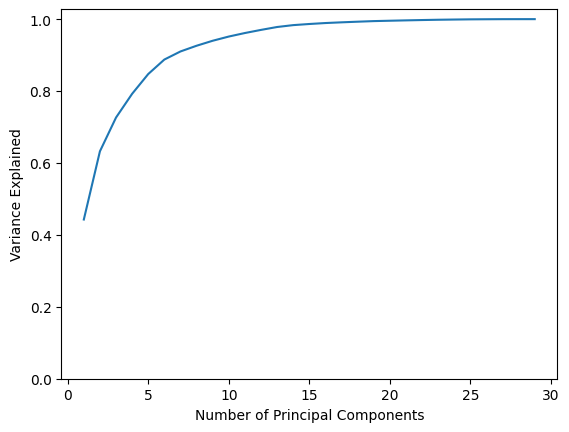

In [84]:
plt.plot(range(1, 30), explained_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')
plt.ylim(0)